# 01 — Calibrate detection on ONE slice

Tune detection on a single section, inspect it against the QC gates, then **lock** the
parameters into `BraiAn.yml` so `02_batch.ipynb` can apply them to the whole series.
This is the pipeline's own rule from `CLAUDE.md`: *tune on ONE section before scaling*.

**Cost split — this is the whole design.**

| | cost | what |
|---|---|---|
| **EXPENSIVE** | ~30 min/slice, QuPath JVM | DAPI detection + measurement export |
| **CHEAP** | seconds, pure pandas | gates, histograms, densities, k-sweep |

There is deliberately **no live slider** on detection parameters — at 30 min a run that
would be theatre. The loop is **tune → run → inspect**.

Expensive cells honour `PARAMS["dry_run"]` and default to **printing** the exact headless
command rather than launching anything. Run this notebook in the `braian` env.

## PARAMS — the only cell you edit

In [13]:
PARAMS = {
    # QuPath project holding BraiAn.yml, pipeline.yml, scripts/ and results/.
    # Relative to the repo root (discovered below); an absolute path also works.
    "project": "M5 Hipp3 080326/M5 Hipp3 080326 QuPath",

    # Which slice to calibrate on. None -> first slice found in results/.
    "slice": None,

    # Safety. True = expensive cells only PRINT their command. Flip deliberately.
    "dry_run": False,

    # Candidate detection params to try. Keys must exist in BraiAn.yml.
    # Empty dict = inspect the params already in BraiAn.yml without changing them.
    "detection": {
        # "sigmaMicrons": 2.0,
        # "minAreaMicrons": 20.0,
        # "maxAreaMicrons": 250.0,
        # "histogramThreshold.nPeak": 2,
    },

    # Final gate: set True only once the QC section below looks right.
    "lock": True,

    # Gate threshold overrides, e.g. {"area_peak_min": 25.0}. See GateThresholds.
    # white_matter/ventricle demoted to advisory 2026-07-28 (operator call): they still
    # report their numbers but no longer drive the verdict. Consequence: DAPI DENSITIES
    # are not trustworthy while this holds; ratio readouts like P(Fos+|TdT+) are fine.
    # Remove the advisory_gates entry to re-arm them.
    "thresholds": {
        "advisory_gates": ("white_matter_density", "ventricle_density"),
    },
}

import sys
from dataclasses import replace
from pathlib import Path

# Repo root is DISCOVERED, not hardcoded. A new user's first act should not be
# editing an absolute path with someone else's username in it -- that is how a lab
# ends up with five divergent copies of the same notebook. Walks up from the working
# directory looking for the repo's own marker files.
def _find_repo_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "scripts" / "cockpit_checks.py").is_file() and (d / "pipeline.yml").is_file():
            return d
    raise FileNotFoundError(
        f"could not find the pipeline repo root at or above {start} -- expected a "
        f"directory holding both scripts/cockpit_checks.py and pipeline.yml. Launch "
        f"JupyterLab from inside the repo, or set REPO = Path('...') by hand here."
    )


REPO = _find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO / "scripts"))


def _under_repo(p) -> Path:
    """PARAMS paths are repo-relative by default; an ABSOLUTE path is honoured as
    given, so a project living outside the repo still works."""
    p = Path(p)
    return p if p.is_absolute() else REPO / p

# ipykernel in this env does not auto-activate the inline backend, so matplotlib
# falls back to the non-interactive Agg canvas and plt.show() silently renders
# nothing ("FigureCanvasAgg is non-interactive"). Make it explicit.
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import cockpit_checks as cc
import cockpit_threshold as ct

PROJECT = _under_repo(PARAMS["project"])
TH = replace(cc.DEFAULT_THRESHOLDS, **PARAMS["thresholds"])
print(f"project : {PROJECT}\ndry_run : {PARAMS['dry_run']}")

project : /home/jflab/Analysis/M5 Hipp3 080326/M5 Hipp3 080326 QuPath
dry_run : False


## 0. `BraiAn.yml` — create it, or check the one that's there &nbsp;<sub>CHEAP</sub>

**Run this first on any new project.** `sync_project.py` deploys the Groovy stages and
merges `pipeline.yml`, but it cannot touch `BraiAn.yml` — that file is **per-acquisition**,
and its `requestedPixelSizeMicrons` must equal the images' own `PhysicalSizeX` exactly. If
it doesn't, BraiAnDetect resamples and **every nucleus area is wrong**, which quietly
corrupts the area gate, the min/max area filters, and every density.

Not hypothetical: on 2026-08-04 M5 Hipp3 (0.690535 µm/px) was given M3 Hipp2's config
(0.460357) — a 33% error, caught only because calibration happened to refuse. The runbook
had even named the wrong project as the copy source.

This removes the guess. It reads pixel size and channel names **off the images**, and:

- **audit** — checks what's already there. Cheap; run it every time.
- **scaffold** — writes a new one, taking detection seeds from the project that shares
  this one's **acquisition regime**, chosen by matching pixel size rather than by you
  remembering which project is which.

**Derived vs supplied.** Pixel size, channel names and the anchor come from the image.
The micron-denominated seeds (`sigmaMicrons`, `min`/`maxAreaMicrons`,
`cellExpansionMicrons`) come from the template — they're judgement calls belonging to a
regime, not to a file. **Z depth cannot be derived**: a MIP has already collapsed it. Set
`Z_PLANES` below and it's recorded in the header. It matters — markers are max-projected,
so 4 planes samples ~3× the cell volume of 2.

Scaffolding **refuses to overwrite** an existing file. Fixing one is an audit plus a
one-line edit; silently replacing a config carrying tuned seeds would throw away exactly
the judgement this pipeline exists to preserve.


In [14]:
# CHEAP — reads the images, writes nothing unless SCAFFOLD is True.
import setup_braian_config as sbc

SCAFFOLD = False        # True -> write a BraiAn.yml (refuses if one already exists)
TEMPLATE = None         # None -> pick the project matching this one's pixel size
Z_PLANES = None         # Z depth of the SOURCE CZI; cannot be read from a MIP
PIXEL_UM = None         # None -> read from the image. Override only if you must.

print("Known acquisition regimes in this repo:")
for r in sbc.known_regimes(REPO):
    print(f"  {str(r['pixel_um'] or '?'):<22} anchor={r['anchor']:<10} {r['project'].name}")
print()

if SCAFFOLD:
    target, actions = sbc.scaffold(PROJECT, TEMPLATE, PIXEL_UM, Z_PLANES,
                                   dry_run=PARAMS["dry_run"])
    for a in actions:
        print(f"  {a}")
    print()

sbc.print_report(PROJECT)

# Anything marked ERROR will produce wrong numbers — fix it before detecting.
# WARN is worth reading but does not change any result.


Known acquisition regimes in this repo:
  0.460357               anchor=DAPI-T4    M3 Hipp1 072326 7 Scene QuPath
  0.460357               anchor=DAPI-T4    M3 Hipp2 072526 QuPath
  0.6905355              anchor=DAPI-T4    M5 073026 QuPath
  0.690535481770835      anchor=DAPI-T4    M5 Hipp3 080326 QuPath
  0.460357               anchor=DAPI-T4    wBA1-2_2-1-tdt-only 072026 project
  0.6905355              anchor=DAPI-T4    wBA_1-3_2-1_072026
  0.6905355              anchor=DAPI-T4    M3 Hippocampus 20x 062926 3 plane

BraiAn.yml audit -- /home/jflab/Analysis/M5 Hipp3 080326/M5 Hipp3 080326 QuPath
  images       : 2 MIP(s), e.g. M5-hipp3_s1_MIP.ome.tiff
  pixel size   : 0.690535481770835
  channels     : ['AF568-T2', 'AF488-T3', 'DAPI-T4']
  anchor       : DAPI-T4

  OK -- BraiAn.yml matches the images.


0

## 1. Config panel — what is currently set

Everything below is read from `pipeline.yml` and `BraiAn.yml`; nothing is hardcoded.

In [15]:
config = cc.load_config(PROJECT)
anchor_ch = cc.anchor_channel(PROJECT)

print("pipeline.yml")
print(f"  anchor   : {config.anchor_name}  (channel {anchor_ch})")
for m in config.markers:
    print(f"  marker   : {m['name']:<6} channel {m['channel']:<12} compartment {m['compartment']}")
print(f"  Double+  : {'yes' if config.emit_double else 'no (needs >=2 markers)'}")
print(f"  exclude  : {sorted(config.exclude_acronyms) or '(none)'}")
print(f"  k_robust : {cc.k_robust(PROJECT):g}")

print("\nBraiAn.yml detection params (what the gates below are judging)")
current = cc.detection_params(PROJECT)
for k, v in current.items():
    marker = "  <- PARAMS override" if k in PARAMS["detection"] else ""
    print(f"  {k:<34} {v}{marker}")

if PARAMS["detection"]:
    print("\nProposed changes:")
    for k, v in PARAMS["detection"].items():
        print(f"  {k:<34} {current.get(k)}  ->  {v}")
else:
    print("\nNo overrides in PARAMS['detection'] — inspecting BraiAn.yml as-is.")

pipeline.yml
  anchor   : DAPI  (channel DAPI-T4)
  marker   : Fos    channel AF488-T3     compartment nuclear
  marker   : TdT    channel AF568-T2     compartment whole-cell
  Double+  : yes
  exclude  : ['DG-sg', 'VS']
  k_robust : 3

BraiAn.yml detection params (what the gates below are judging)
  channel                            DAPI-T4
  classForDetections                 allen_mouse_10um_java
  requestedPixelSizeMicrons          0.690535481770835
  sigmaMicrons                       2.0
  minAreaMicrons                     20.0
  maxAreaMicrons                     250.0
  cellExpansionMicrons               5.0
  backgroundRadiusMicrons            10
  medianRadiusMicrons                0.0
  watershedPostProcess               True

No overrides in PARAMS['detection'] — inspecting BraiAn.yml as-is.


## 1b. Every knob, and which way to move it &nbsp;<sub>CHEAP</sub>

The full tuning surface in one table — MIP/seam knobs, detection knobs, and
classification knobs — with each one's current value and the direction to move it.

The three stages keep their settings in different places on purpose (`BraiAn.yml` is
BraiAnDetect's own params file, `pipeline.yml` is the marker/classification config,
and the MIP knobs are `czi_mip.py` command-line arguments). `cockpit_tune` reads and
writes all of them, so this is one control surface over files that stay separate.

Full reference, including what each knob does to the image: `docs/runbook/03-tuning.md`.


In [16]:
import cockpit_tune as tune

tune.print_knobs(PROJECT)


Tuning knobs for /home/jflab/Analysis/M5 Hipp3 080326/M5 Hipp3 080326 QuPath

  mip       feather_margin                   default 130  pass to czi_mip.py  seam blend width, px, for the per-scene tile stitch
                                                                              -> RAISE to soften visible seams; LOWER to keep tile edges crisp
  mip       flat_field                      default True  pass to czi_mip.py  retrospective per-channel shading correction (--no-flat-field disables)
                                                                              -> DISABLE to test whether shading estimation is itself causing banding
  mip       dapi_z                          default None  pass to czi_mip.py  force the anchor focus plane (0-based Z) instead of the automatic pick
                                                                              -> SET when the var-of-Laplacian pick disagrees with your eye
  mip       scenes                          default None  pa

### Change a knob

Edit `TUNE` below and run. Each knob is routed to the correct config file, and your
comments in those files are preserved. Respects `PARAMS["dry_run"]`.

**Change one knob at a time** — two at once and the tuning log cannot tell you which
one moved the numbers. MIP/seam knobs are not settable here; pass them to
`czi_mip.py` (see the markdown above section 1b).


In [9]:
# e.g. {"sigmaMicrons": 2.5} or {"span_frac": 0.30}. Empty = change nothing.
TUNE = {}

if not TUNE:
    print("TUNE is empty — nothing to change.")
elif PARAMS["dry_run"]:
    args = " ".join(f"--set {k}={v}" for k, v in TUNE.items())
    print("dry_run — would run:")
    print(f'  python3 scripts/cockpit_tune.py --project "{PROJECT}" {args} --deploy')
else:
    tune.apply_sets(PROJECT, [f"{k}={v}" for k, v in TUNE.items()])
    tune.validate_config(PROJECT)
    tune.deploy(PROJECT)


TUNE is empty — nothing to change.


## 2. Pick the calibration slice

In [4]:
slices, from_exports = cc.find_candidate_slices(PROJECT)

if from_exports:
    print(f"{len(slices)} slice(s) with exports in results/:")
    for s in slices:
        print(f"  {s.label:<24} regions={'y' if s.regions_tsv else '-'} "
              f"percell={'y' if s.percell_tsv else '-'}")
else:
    # Nothing detected/exported yet -- fall back to the QuPath project's own entries
    # so a FRESH project can be calibrated. Without this, section 2 and section 4 are
    # circular: you could not pick a slice to detect on until a detection had been
    # exported for it.
    print(f"No exports in results/ yet -- listing the {len(slices)} QuPath entries:")
    for s in slices:
        print(f"  {s.label}")
    print("\n(Gates in section 5 will report N/A until section 4 has run.)")

if PARAMS["slice"]:
    hits = [s for s in slices if s.label == PARAMS["slice"]]
    if not hits:
        raise SystemExit(f"slice {PARAMS['slice']!r} not found; choose from "
                         f"{[s.label for s in slices]}")
    SLICE = hits[0]
else:
    SLICE = slices[0]

# Map the slice back to its QuPath image entry name (what --image expects).
IMAGE = next((n for n in cc.project_image_names(PROJECT) if n.endswith(SLICE.label)), None)
print(f"\ncalibrating on : {SLICE.label}")
print(f"QuPath entry   : {IMAGE or '(not matched in project.qpproj)'}")


1 slice(s) with exports in results/:
  M5-hipp3_s1              regions=y percell=y

calibrating on : M5-hipp3_s1
QuPath entry   : M5-hipp3_s1_MIP.ome.tiff - M5-hipp3_s1


## 3. Detection threshold — calibrate & visualize &nbsp;<sub>EXPENSIVE, then CHEAP</sub>

The anchor-channel intensity cut that decides which pixels are a nucleus. This replaces
the old `find_threshold().groovy` sweep, which hardwired the channel name and swept
`peakProminence` — a knob that changes *which peak is found*, not where the cut sits.

**The rule** (`detection_threshold` in `pipeline.yml`):

$$\text{threshold} = \text{floor} + \texttt{span\_frac} \times (\text{bright peak} - \text{floor})$$

Both endpoints are re-measured from **each section's own histogram**, so the cut follows
staining and laser drift instead of being pinned to whichever section it was tuned on.
That is what keeps counts comparable across sections, animals and acquisitions — and it
is why a fixed absolute threshold (the previous `threshold: 700`) had to go.

`calibrate_threshold.groovy` is read-only: it changes no objects and is safe to re-run.
It writes `<image>__threshold_calibration.json`, which the next cell plots.

**Reading the plot.** Shaded band = floor → bright peak. Solid red line = the chosen cut.
Too near the floor and background is detected as nuclei; too near the bright peak and dim
real nuclei are dropped — the failure mode the reference workflow reports as destroying
regional contrast. The lower quarter of the span is the working range.


In [ ]:
# EXPENSIVE — runs QuPath on one slice. Read-only: no objects are modified.
calib_script = PROJECT / "scripts" / "calibrate_threshold.groovy"

if not calib_script.exists():
    print(f"calibrate_threshold.groovy not deployed in {PROJECT/'scripts'}.")
    print("Deploy the pipeline into this project (also removes retired scripts):")
    print(f'  python3 {REPO}/scripts/sync_project.py --project "{PROJECT}"')
else:
    calib_cmd = cc.qupath_command(PROJECT, calib_script, image=IMAGE, save=False)
    cc.run_qupath(calib_cmd, dry_run=PARAMS["dry_run"],
                  log_path=PROJECT / "results" / f"{SLICE.label}__threshold_calibration.log")

print("\nThreshold rule currently configured in pipeline.yml:")
_cfg = ct.load_config_threshold(PROJECT)
for k, v in _cfg.items():
    print(f"  {k:<18} {v}")


In [ ]:
# CHEAP — pure pandas/matplotlib over the calibration JSONs already on disk.
calibs = ct.find_calibrations(PROJECT)

if not calibs:
    print("No *__threshold_calibration.json in results/ yet.")
    print("Run the cell above with dry_run=False (or run calibrate_threshold.groovy in QuPath).")
else:
    ct.print_report(PROJECT)

    # This slice: where the cut lands on the real histogram, and what the knob would do.
    this = next((c for c in calibs if SLICE.label in c.image), calibs[0])
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.2),
                             gridspec_kw={"width_ratios": [1.75, 1]})
    ct.plot_histogram(this, ax=axes[0])
    ct.plot_sweep(this, ax=axes[1])
    plt.tight_layout()
    plt.show()

    # Whole series: a section whose floor/bright peak is unlike its siblings is an
    # acquisition inconsistency, worth catching before spending a batch run on it.
    if len(calibs) > 1:
        ct.plot_series(calibs)
        plt.tight_layout()
        plt.show()


## 3b. Set the threshold by LOOKING at it &nbsp;<sub>CHEAP — interactive</sub>

Reads the **MIP directly** (no QuPath, no JVM), samples crops from different parts of the
section, and draws the above-cut mask so you can scrub a slider and watch it land on
nuclei or flood the tissue. **This is not a detection slider** — detection still costs
~30 min and is not previewed. What is instant is the threshold decision itself.

### Per-slice by eye is a first-class method, not a fallback

`span_frac: 0.25` is **tier-3 evidence** — seeded from one operator call on one section,
never validated against hand counts. A cut you set while looking at the mask is **tier-1
(SEEN)**, and by this project's own evidence hierarchy it outranks the rule. The rule
misfired or looked suspect on **5 of 16 sections** run here (31%):

| section | it got | why |
|---|---|---|
| `M5-hipp3_s1` | 123 | trimodal; finder took two background peaks |
| `M5c_s3` / `s4` | 1073 / 1009 | no separable floor at all |
| `M5a_s1` | 104 | bright peak 253 vs ~5,000 for siblings |

So set every slice by eye if that is what the images need. `threshold_overrides` in
`pipeline.yml` is built to carry a whole series.

**The one cost, and how it is controlled.** A mechanical rule has no operator variance;
sixteen by-eye calls do. If your eye drifts over a session, that drift becomes an
AP-position gradient in the counts and reads as biology. So:

- **Record each call** (the ledger at the bottom) — inspectable, not recalled.
- **Watch the implied span fraction** printed with every cut: where your choice sits on
  *that section's own* floor→bright span. Stable across slices ⇒ your eye and the rule
  agree. Varying ⇒ no single rule fits, which is exactly what per-slice is for.
- **One visual criterion every time**: mask covers nuclei, leaves the gaps alone.
- **Set blind to condition** where the group comparison matters.

The rule keeps one real advantage — it reproduces without a human, so a re-run years
later gives the same numbers. Prefer it where it demonstrably works.

### What the preview gets right that the QuPath-side rule does not

1. **Coarse histogram bins.** BraiAn finds peaks at native 16-bit resolution, where
   near-zero background carries enough wrinkles to supply a false second peak. On
   `M5-hipp3_s1`: 4096 bins → cut **120**; 512 bins → cut **1600**. Same image, same
   finder.
2. **Background subtraction before masking** (`backgroundRadiusMicrons: 10`) — masking
   raw would mislead badly, since tissue autofluorescence alone sits near 5,600 here.
3. **Crops sampled across the tissue range**, not the brightest windows — a cut that is
   too low shows itself first in *sparse* regions.

**How to read it.** Red mask should pick out nuclei and leave the space between them
alone. Flooding = too low. Dim nuclei disappearing = too high. The coverage line is
orientation only, tagged `<internal>` from three of our own sections — **your eye
outranks it**.

**Workflow.** Set a cut you believe → **Record this slice** → next slice from the `image`
dropdown → repeat. The ledger at the bottom emits the complete `threshold_overrides:`
block to paste into `<project>/pipeline.yml`.

In [ ]:
# CHEAP — reads the MIP directly. No QuPath, no JVM, nothing is written.
import cockpit_threshold_gui as gui

# Loading one channel of a MIP takes a few seconds; every slider move after that is
# instant because the plane and its histogram are cached.
THRESHOLD = gui.launch(PROJECT)

# THRESHOLD is a live dict — after settling on a cut, read it back here rather than
# retyping what you just chose:
#     THRESHOLD["threshold"], THRESHOLD["method"], THRESHOLD["span_frac"]


## 3c. Set the MARKER cuts (`k_robust`) by eye &nbsp;<sub>CHEAP — interactive</sub>

Same idea as 3b, one stage later. 3b set the **anchor** cut — which pixels are a nucleus.
This sets the **marker** cuts — which of those nuclei are TdT+ / Fos+ / Double+, i.e. every
engram number the pipeline produces.

**Cheap for a structural reason.** `k_robust` is applied *after* detection, to
`<marker>_bgsub` in the per-cell export — the exact column `02_detect_classify.groovy`
thresholds. Sweeping k needs no QuPath, no re-detection, no image re-processing. Seconds,
not the ~30 minutes a detection re-run costs.

The picker shows the marker channel with cells ringed — filled where positive at the
current k, hollow where not — plus the whole-section bg-sub distribution with the cut drawn
on it. **The picture is a crop; the cut is always derived from the whole section's
classifiable population**, exactly as the pipeline derives it. A cut computed from the crop
would move as you scrolled.

**Why by eye at all.** TdT's `k_robust: 2.0` came from one by-eye call on M3 Hipp2 s3 on
2026-07-30 and has been copied into every project since — tier-3 evidence propagated by
copy-paste. Looking at the cells is tier-1.

It **writes nothing**; it prints a paste-ready `markers:` block, same as the anchor picker.

### Judging it

Ring a cell Double+ only if it looks positive in **both** channels when you flip between
them. The failure mode to watch for is TdT ringing bystander nuclei that a passing axon runs
through — whole-cell measurement picks that up, and it inflates Double+. The lever for that
is `cellExpansionMicrons` down, not k up.

**Do not tune k to move the above-chance overlap.** That number has a technical floor which
*also* moves with k — on M3 Hipp2 the anchor pseudo-marker (zero engram biology by
construction) reads 1.26 at k=1.5 rising to 1.78 at k=10. Tuning until the overlap "looks
right" is tuning against an `<assumed>` number, which the evidence hierarchy forbids. Set k
from the cells, then see what it did:

```bash
python3 scripts/k_vs_chance.py --project "<project>"
```


In [ ]:
# CHEAP — reads the per-cell export + one MIP crop. No QuPath, nothing written.
import cockpit_marker_gui as mg

# marker=None -> a dropdown over every marker in pipeline.yml.
# Pass e.g. marker="TdT" to open straight on one.
mg.launch(project=PROJECT, marker=None)

# Needs *__percell_export.tsv, i.e. section 4 must have run at least once on this
# slice. Changing k afterwards does NOT need another detection pass -- k is applied
# to the exported measurement. Re-run section 4 only once k is settled.


## 4. Detect this one slice &nbsp;<sub>EXPENSIVE — ~30 min</sub>

Writes `PARAMS["detection"]` into `BraiAn.yml` (**after backing it up**), then runs
detection → classification → export on this slice alone. `--save` is included: without it
QuPath discards the result and the half-hour is wasted.

In [6]:
if PARAMS["detection"] and not PARAMS["dry_run"]:
    yml, bak = cc.lock_detection_params(PROJECT, PARAMS["detection"])
    print(f"staged params into {yml.name}   (backup: {bak.name})")
elif PARAMS["detection"]:
    print("DRY RUN — would stage into BraiAn.yml (backup first):")
    for k, v in PARAMS["detection"].items():
        print(f"    {k} = {v}")
else:
    print("No PARAMS['detection'] overrides — using BraiAn.yml as-is.")

STAGES = ["run_braian_detection.groovy", "02_detect_classify.groovy",
          "03_export_region_table.groovy"]

print(f"\nPipeline for {SLICE.label} ({len(STAGES)} stages):")
for script in STAGES:
    cmd = cc.qupath_command(PROJECT, script, image=IMAGE)
    rc = cc.run_qupath(cmd, dry_run=PARAMS["dry_run"],
                       log_path=PROJECT / "results" / f"{SLICE.label}__{Path(script).stem}.log")
    if rc > 0:
        raise RuntimeError(f"{script} failed with exit {rc} — see the log above")

No PARAMS['detection'] overrides — using BraiAn.yml as-is.

Pipeline for M5-hipp3_s1 (3 stages):
RUNNING:
  /home/jflab/section-pipeline/tools/QuPath/bin/QuPath script -p '/home/jflab/Analysis/M5 Hipp3 080326/M5 Hipp3 080326 QuPath/project.qpproj' -i 'M5-hipp3_s1_MIP.ome.tiff - M5-hipp3_s1' -s '/home/jflab/Analysis/M5 Hipp3 080326/M5 Hipp3 080326 QuPath/scripts/run_braian_detection.groovy'
  log -> /home/jflab/Analysis/M5 Hipp3 080326/M5 Hipp3 080326 QuPath/results/M5-hipp3_s1__run_braian_detection.log  (118 lines)
  18:51:21.862 [task-runner-1-3] [INFO ] q.lib.plugins.DetectionPluginTools - 3934 nuclei detected (processing time: 7.94 seconds)
  18:51:21.863 [main] [INFO ] q.l.p.CommandLineTaskRunner$CommandLineProgressMonitor - 3934 nuclei detected (85%)
  18:51:22.410 [task-runner-1-5] [INFO ] q.lib.plugins.DetectionPluginTools - 2661 nuclei detected (processing time: 4.22 seconds)
  18:51:22.410 [main] [INFO ] q.l.p.CommandLineTaskRunner$CommandLineProgressMonitor - 2661 nuclei dete

## 5. QC self-checks &nbsp;<sub>CHEAP</sub>

Each gate prints its measured **number** next to a PASS/FLAG verdict. Advisory gates
inform but never decide the overall verdict.

In [7]:
results = cc.run_all_gates(SLICE, PROJECT, TH, config, anchor_ch)
cc.print_gates(SLICE.label, results)

blocking = [r for r in results if r.is_flag and not r.advisory]
print("\n" + ("All blocking gates PASS — parameters look sane on this slice."
              if not blocking else
              "Blocking gate(s) flagged: " + ", ".join(r.name for r in blocking)
              + "\nAdjust PARAMS['detection'] and re-run section 4, or — if the number is"
                "\nright for this prep and the BAND is what is wrong — widen it via"
                "\nPARAMS['thresholds'] and record why."))


M5-hipp3_s1  ->  PASS
  [            PASS] nucleus_area_peak_um2      =       27.5  <assumed>    modal bin of 276,889 nuclei; expect 25-150 um^2
  [            PASS] k_swing_pp                 =        1.7  <internal>   P(Fos+|TdT+) [k=2:38.7%, k=2.5:37.9%, k=3:37.0%]; max swing 10 pp
  [ FLAG (advisory)] white_matter_density       =    5,442.5  <anatomical> worst='int' 5,442/mm^2 vs cortex 4,835/mm^2 (ratio 1.13)  <-- 1.13x cortex > 0.6x; > 1500/mm^2; DAPI haze likely  [demoted to advisory]
  [ FLAG (advisory)] ventricle_density          =    2,265.2  <anatomical> 'VS'; expect <= 500/mm^2  <-- detections inside ventricle  [demoted to advisory]
  [ FLAG (advisory)] grey_density_median        =    5,087.2  <assumed>    0/7 regions inside 500-2000/mm^2 (Isocortex 4,835, CA1 5,289, CA3 5,087, DG 5,488, TH 5,397, HY 5,078, STR 4,673)
  [            PASS] total_density              =    4,969.8  <assumed>    276,888 detections over 55.7 mm^2 registered; expect 300-8000/mm^2

All blocking g

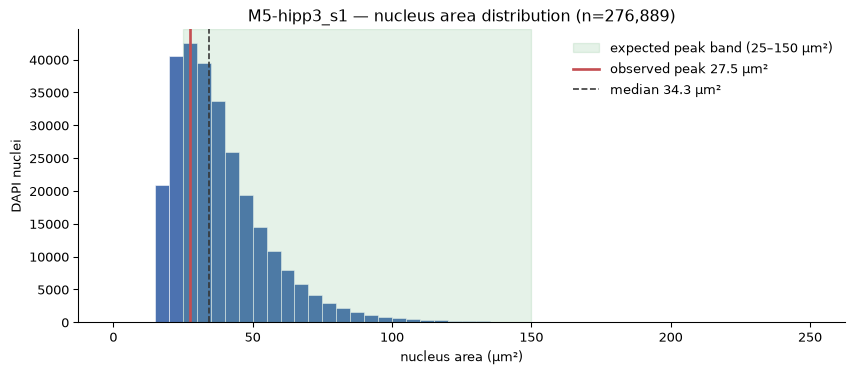

In [8]:
# Nucleus area histogram — the shape behind the area gate.
percell = cc.load_percell_for_slice(SLICE)
areas = pd.to_numeric(percell["nucleus_area_um2"], errors="coerce")
areas = areas[np.isfinite(areas) & (areas > 0)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(areas, bins=np.arange(0, min(areas.max(), TH.area_peak_max * 4) + TH.area_bin_width,
                              TH.area_bin_width), color="#4C72B0", edgecolor="white", linewidth=0.4)
ax.axvspan(TH.area_peak_min, TH.area_peak_max, color="#55A868", alpha=0.15,
           label=f"expected peak band ({TH.area_peak_min:g}–{TH.area_peak_max:g} µm²)")
peak = next(r for r in results if r.name == "nucleus_area_peak_um2").value
if np.isfinite(peak):
    ax.axvline(peak, color="#C44E52", lw=2, label=f"observed peak {peak:.1f} µm²")
ax.axvline(float(areas.median()), color="#333", lw=1.2, ls="--",
           label=f"median {areas.median():.1f} µm²")
ax.set(xlabel="nucleus area (µm²)", ylabel=f"{config.anchor_name} nuclei",
       title=f"{SLICE.label} — nucleus area distribution (n={len(areas):,})")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

region,count,area_mm2,density_per_mm2
Isocortex,"75,152",15.544,"4,835"
cc,"6,016",1.124,"5,354"
int,"5,874",1.079,"5,442"
fiber tracts,"34,179",6.633,"5,153"
VS,"1,332",0.588,"2,265"


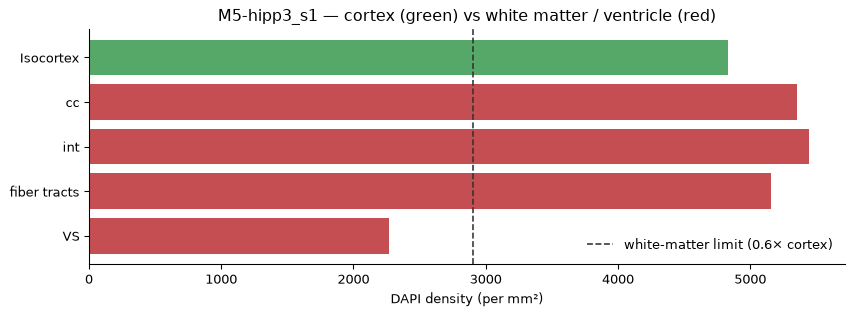

In [10]:
# Region densities behind the white-matter / ventricle gates.
if SLICE.regions_tsv is not None:
    regions = cc.load_regions_tsv(SLICE.regions_tsv, anchor_ch)
    show = list(TH.cortex_acronyms) + list(TH.white_matter_acronyms) + list(TH.ventricle_acronyms)
    rows = [(a, *cc.region_density(regions, a)) for a in show]
    rows = [(a, c, ar, d) for a, c, ar, d in rows if np.isfinite(d)]
    dens = pd.DataFrame(rows, columns=["region", "count", "area_mm2", "density_per_mm2"])
    display(dens.style.format({"count": "{:,.0f}", "area_mm2": "{:.3f}",
                               "density_per_mm2": "{:,.0f}"}).hide(axis="index"))

    cortex = np.mean([cc.region_density(regions, a)[2] for a in TH.cortex_acronyms])
    fig, ax = plt.subplots(figsize=(9, 3.4))
    colors = ["#55A868" if r in TH.cortex_acronyms else "#C44E52" for r in dens["region"]]
    ax.barh(dens["region"], dens["density_per_mm2"], color=colors)
    ax.axvline(cortex * TH.white_matter_ratio_max, color="#333", ls="--", lw=1.2,
               label=f"white-matter limit ({TH.white_matter_ratio_max:g}× cortex)")
    ax.set(xlabel=f"{config.anchor_name} density (per mm²)",
           title=f"{SLICE.label} — cortex (green) vs white matter / ventricle (red)")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("no regions.tsv for this slice — density plot skipped")

## 6. Lock the parameters

Commits `PARAMS["detection"]` into `BraiAn.yml` so `02_batch.ipynb` applies exactly these
numbers to every slice. The file is backed up first, values are edited **in place** so the
comments recording *why* each number is what it is survive, and every write is verified by
re-parsing. Requires `PARAMS["lock"] = True` — an explicit, deliberate act.

In [17]:
if not PARAMS["lock"]:
    print("PARAMS['lock'] is False — nothing written.")
    print("Set it True (with PARAMS['detection'] filled in) once the gates above look right.")
elif not PARAMS["detection"]:
    print("PARAMS['lock'] is True but PARAMS['detection'] is empty — nothing to lock.")
elif blocking:
    print("Refusing to lock: blocking gate(s) still flagged — "
          + ", ".join(r.name for r in blocking))
    print("Fix the parameters, or widen the band in PARAMS['thresholds'] if the band is "
          "what is wrong, then re-run.")
else:
    yml, bak = cc.lock_detection_params(PROJECT, PARAMS["detection"])
    print(f"LOCKED into {yml}\nbackup   {bak}")
    for k, v in cc.detection_params(PROJECT).items():
        print(f"  {k:<34} {v}{'  <- locked' if k in PARAMS['detection'] else ''}")
    print("\nNext: run 02_batch.ipynb to apply these to the whole series.")

PARAMS['lock'] is True but PARAMS['detection'] is empty — nothing to lock.


## 7. Record this tuning round &nbsp;<sub>CHEAP</sub>

Appends the current parameter set plus the resulting numbers (modal nucleus area,
density, Fos+/TdT+ fractions) to `<project>/results/tuning_log.csv`.

Run this **after** you have looked at the result and formed an opinion — the note is
the part your future self actually needs. It makes "the settings from two rounds ago
looked better" an answerable question rather than a memory test.


In [18]:
NOTE = "Should increase k for tdt, lets add interactive gui for k threshold adjustment like the DAPI"   # e.g. "seams less visible, nuclei still a bit small"

if PARAMS["dry_run"]:
    print("dry_run — would run:")
    print(f'  python3 scripts/cockpit_tune.py --project "{PROJECT}" --log --note "{NOTE}"')
else:
    tune.log_round(PROJECT, NOTE)
    log_csv = PROJECT / "results" / "tuning_log.csv"
    if log_csv.exists():
        display(pd.read_csv(log_csv))


  round 1 appended -> /home/jflab/Analysis/M5 Hipp3 080326/M5 Hipp3 080326 QuPath/results/tuning_log.csv


,round,timestamp,sigmaMicrons,minAreaMicrons,maxAreaMicrons,cellExpansionMicrons,backgroundRadiusMicrons,requestedPixelSizeMicrons,span_frac,peak_prominence,smooth_window,k_robust,gap_um,width_um,note
0,1,2026-08-04 19:19,2.0,20.0,250.0,5.0,10,0.690535,0.25,100,15,3.0,1.0,8.0,"Should increase k for tdt, lets add interactiv..."
